# Лабораторная работа №1: Классификация с помощью персептрона

**Дисциплина:** Генетические и эволюционные вычисления

**Цель работы:** изучить принцип работы персептрона Розенблатта и применить его для задач классификации.

В данной лабораторной работе мы:
1. Реализуем однослойный персептрон с нуля (на NumPy) для классификации на 2 класса.
2. Продемонстрируем проблему XOR — невозможность линейного разделения.
3. Построим персептрон из двух нейронов для классификации на 4 класса.

### Импорт библиотек

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.express as px
from pathlib import Path

Path("report/outputs").mkdir(exist_ok=True)

np.random.seed(42)

---
## Задание 1: Персептрон для классификации на 2 класса

Персептрон — простейшая модель искусственного нейрона. Он принимает вектор входов $\mathbf{x} = (x_1, x_2)$, вычисляет взвешенную сумму и применяет пороговую функцию активации:

$$y = \begin{cases} 1, & \text{если } \mathbf{w} \cdot \mathbf{x} + b \geq 0 \\ 0, & \text{иначе} \end{cases}$$

**Правило обучения персептрона:**
$$\mathbf{w}_{\text{new}} = \mathbf{w}_{\text{old}} + \eta \cdot (t - y) \cdot \mathbf{x}$$
$$b_{\text{new}} = b_{\text{old}} + \eta \cdot (t - y)$$

где $t$ — целевое значение, $y$ — выход персептрона, $\eta$ — скорость обучения.

**Входные данные:**
```
p = [[-0.5, -0.5, +0.3, -0.1],
     [-0.5, +0.5, -0.5, +1.0]]
t = [0, 0, 1, 1]
```

In [2]:
class Perceptron:
    """Однослойный персептрон с пороговой функцией активации."""

    def __init__(self, n_inputs, learning_rate=1.0):
        self.weights = np.zeros(n_inputs)
        self.bias = 0.0
        self.lr = learning_rate
        self.errors_per_epoch = []
        self.weights_history = []
        self.bias_history = []

    def activation(self, x):
        return 1 if x >= 0 else 0

    def predict(self, x):
        return self.activation(np.dot(self.weights, x) + self.bias)

    def predict_batch(self, X):
        return np.array([self.predict(x) for x in X])

    def fit(self, X, t, max_epochs=100):
        """
        Обучение персептрона.
        X: массив (n_samples, n_features)
        t: массив целевых значений (n_samples,)
        """
        self.errors_per_epoch = []
        self.weights_history = []
        self.bias_history = []

        self.weights_history.append(self.weights.copy())
        self.bias_history.append(self.bias)

        for epoch in range(max_epochs):
            errors = 0
            for xi, ti in zip(X, t):
                y = self.predict(xi)
                error = ti - y
                if error != 0:
                    self.weights += self.lr * error * xi
                    self.bias += self.lr * error
                    errors += 1
            self.errors_per_epoch.append(errors)
            self.weights_history.append(self.weights.copy())
            self.bias_history.append(self.bias)

            if errors == 0:
                print(f"Сходимость достигнута на эпохе {epoch + 1}")
                break
        else:
            print(f"Обучение завершено после {max_epochs} эпох (сходимость не достигнута)")

        return self

In [3]:
p = np.array([[-0.5, -0.5, +0.3, -0.1],
              [-0.5, +0.5, -0.5, +1.0]])
t = np.array([0, 0, 1, 1])

X = p.T  # (4, 2) — каждая строка это вектор признаков

print("Входные векторы (столбцы p → строки X):")
for i, (xi, ti) in enumerate(zip(X, t)):
    print(f"  x{i+1} = {xi}, класс = {ti}")

Входные векторы (столбцы p → строки X):
  x1 = [-0.5 -0.5], класс = 0
  x2 = [-0.5  0.5], класс = 0
  x3 = [ 0.3 -0.5], класс = 1
  x4 = [-0.1  1. ], класс = 1


In [4]:
perc1 = Perceptron(n_inputs=2, learning_rate=1.0)
perc1.fit(X, t)

print(f"\nНайденные параметры:")
print(f"  Веса: w = {perc1.weights}")
print(f"  Смещение: b = {perc1.bias}")

predictions = perc1.predict_batch(X)
print(f"\nРезультаты классификации:")
print(f"  Целевые значения: {t}")
print(f"  Предсказания:     {predictions}")
print(f"  Все верно: {np.all(predictions == t)}")

Сходимость достигнута на эпохе 3

Найденные параметры:
  Веса: w = [2.  0.5]
  Смещение: b = 0.0

Результаты классификации:
  Целевые значения: [0 0 1 1]
  Предсказания:     [0 0 1 1]
  Все верно: True


### Визуализация: входные точки и разделяющая граница

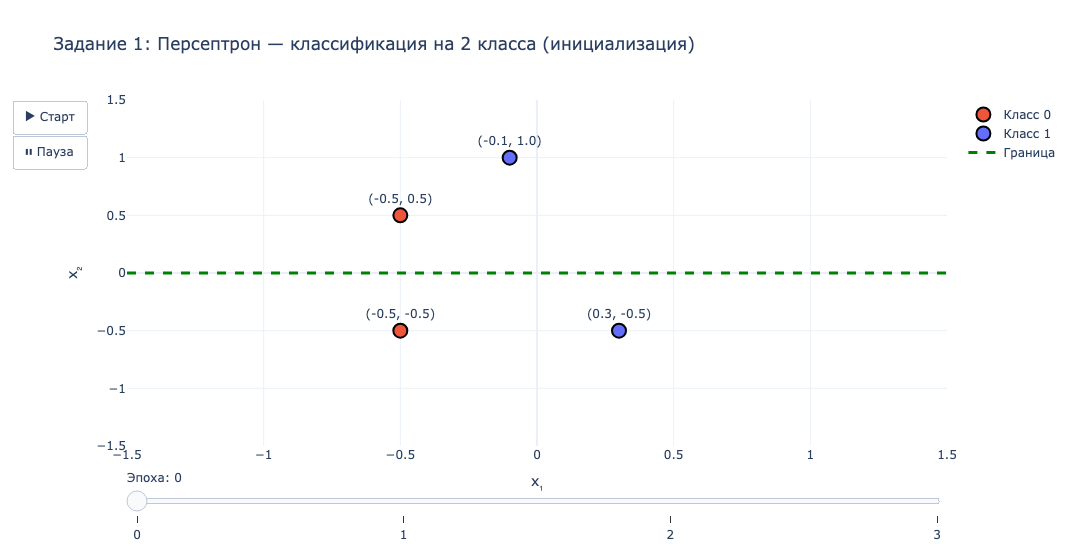

In [5]:
fig = go.Figure()

colors = ['#EF553B', '#636EFA']
class_names = ['Класс 0', 'Класс 1']

for cls in [0, 1]:
    mask = t == cls
    fig.add_trace(go.Scatter(
        x=X[mask, 0], y=X[mask, 1],
        mode='markers+text',
        marker=dict(size=14, color=colors[cls], line=dict(width=2, color='black')),
        text=[f'({x[0]}, {x[1]})' for x in X[mask]],
        textposition='top center',
        name=class_names[cls]
    ))

x_line = np.linspace(-1.5, 1.5, 100)

def decision_boundary_xy(weights, bias, y_limits=(-2, 2)):
    if abs(weights[1]) > 1e-9:
        return x_line, -(weights[0] * x_line + bias) / weights[1]
    if abs(weights[0]) > 1e-9:
        x_val = -bias / weights[0]
        return np.array([x_val, x_val]), np.array(y_limits)
    return x_line, np.zeros_like(x_line)

x0, y0 = decision_boundary_xy(perc1.weights_history[0], perc1.bias_history[0])
fig.add_trace(go.Scatter(
    x=x0, y=y0,
    mode='lines',
    line=dict(color='green', width=3, dash='dash'),
    name='Граница'
))

frames = []
for epoch_idx, (w_f, b_f) in enumerate(zip(perc1.weights_history, perc1.bias_history)):
    x_f, y_f = decision_boundary_xy(w_f, b_f)
    subtitle = 'инициализация' if epoch_idx == 0 else f'эпоха {epoch_idx}, ошибок: {perc1.errors_per_epoch[epoch_idx - 1]}'
    frames.append(go.Frame(
        data=[go.Scatter(x=x_f, y=y_f)],
        traces=[2],
        name=str(epoch_idx),
        layout=go.Layout(title=f'Задание 1: Персептрон — классификация на 2 класса ({subtitle})')
    ))

fig.frames = frames

fig.update_layout(
    title='Задание 1: Персептрон — классификация на 2 класса (инициализация)',
    xaxis_title='x₁', yaxis_title='x₂',
    xaxis=dict(range=[-1.5, 1.5]),
    yaxis=dict(range=[-1.5, 1.5]),
    template='plotly_white',
    width=700, height=550,
    updatemenus=[dict(
        type='buttons',
        showactive=False,
        buttons=[
            dict(label='▶ Старт', method='animate', args=[None, dict(frame=dict(duration=700, redraw=True), fromcurrent=True)]),
            dict(label='⏸ Пауза', method='animate', args=[[None], dict(frame=dict(duration=0, redraw=False), mode='immediate')]),
        ]
    )],
    sliders=[dict(
        active=0,
        currentvalue=dict(prefix='Эпоха: '),
        steps=[
            dict(
                method='animate',
                args=[[str(i)], dict(frame=dict(duration=0, redraw=True), mode='immediate')],
                label=str(i)
            )
            for i in range(len(frames))
        ]
    )]
)
fig.write_html('report/outputs/task1_decision_boundary.html')
fig.show()

### Сходимость обучения

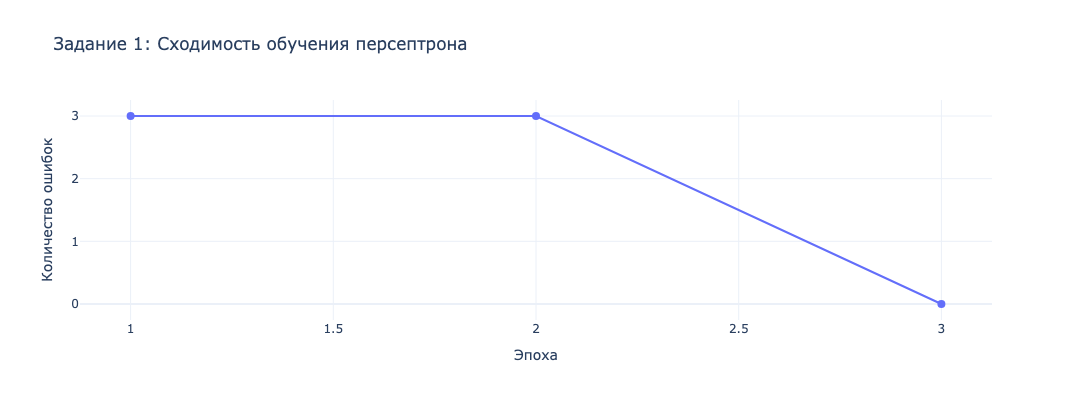

In [6]:
fig_conv = go.Figure()
fig_conv.add_trace(go.Scatter(
    x=list(range(1, len(perc1.errors_per_epoch) + 1)),
    y=perc1.errors_per_epoch,
    mode='lines+markers',
    marker=dict(size=8, color='#636EFA'),
    line=dict(width=2),
    name='Ошибки'
))
fig_conv.update_layout(
    title='Задание 1: Сходимость обучения персептрона',
    xaxis_title='Эпоха',
    yaxis_title='Количество ошибок',
    yaxis=dict(dtick=1),
    template='plotly_white',
    width=700, height=400
)
fig_conv.write_html('report/outputs/task1_convergence.html')
fig_conv.show()

---
## Задание 2: Проблема XOR

Функция XOR (исключающее ИЛИ) — классический пример задачи, которую **невозможно решить** одним персептроном, поскольку классы не являются **линейно разделимыми**.

| $x_1$ | $x_2$ | XOR |
|:---:|:---:|:---:|
| 0 | 0 | 0 |
| 0 | 1 | 1 |
| 1 | 0 | 1 |
| 1 | 1 | 0 |

Невозможно провести одну прямую линию, которая разделит точки классов 0 и 1. Для решения задачи XOR необходим как минимум **двухслойный** персептрон (или многослойная нейронная сеть).

In [7]:
p_xor = np.array([[0, 0, 1, 1],
                   [0, 1, 0, 1]])
t_xor = np.array([0, 1, 1, 0])

X_xor = p_xor.T

print("Входные данные XOR:")
for i, (xi, ti) in enumerate(zip(X_xor, t_xor)):
    print(f"  x = {xi}, класс = {ti}")

Входные данные XOR:
  x = [0 0], класс = 0
  x = [0 1], класс = 1
  x = [1 0], класс = 1
  x = [1 1], класс = 0


In [8]:
MAX_EPOCHS_XOR = 50

perc_xor = Perceptron(n_inputs=2, learning_rate=1.0)
perc_xor.fit(X_xor, t_xor, max_epochs=MAX_EPOCHS_XOR)

print(f"\nПараметры после обучения:")
print(f"  Веса: w = {perc_xor.weights}")
print(f"  Смещение: b = {perc_xor.bias}")

predictions_xor = perc_xor.predict_batch(X_xor)
print(f"\nРезультаты:")
print(f"  Целевые:     {t_xor}")
print(f"  Предсказания: {predictions_xor}")
print(f"  Все верно: {np.all(predictions_xor == t_xor)}")

Обучение завершено после 50 эпох (сходимость не достигнута)

Параметры после обучения:
  Веса: w = [-1.  0.]
  Смещение: b = 0.0

Результаты:
  Целевые:     [0 1 1 0]
  Предсказания: [1 1 0 0]
  Все верно: False


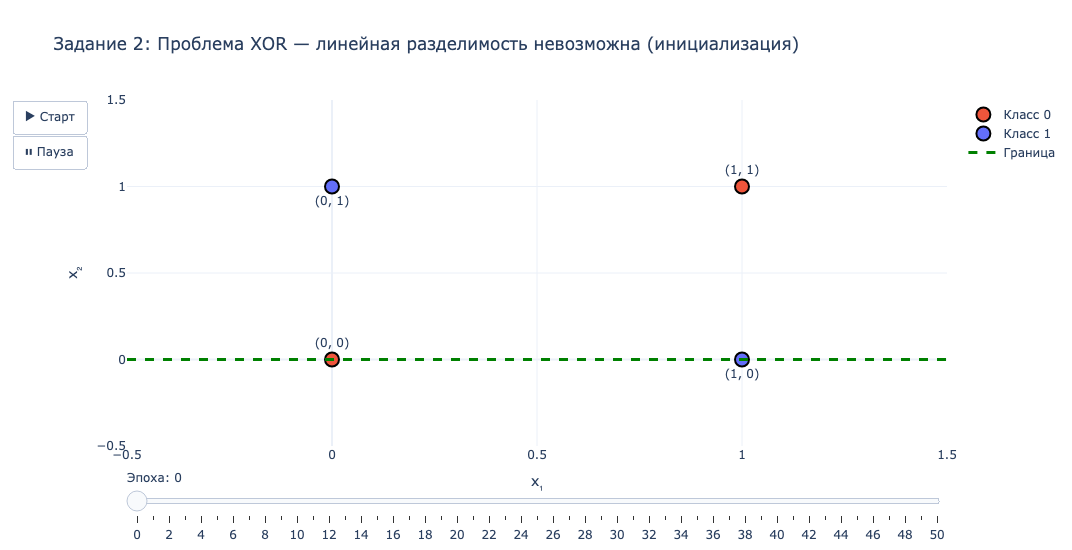

In [9]:
fig_xor = go.Figure()

for cls in [0, 1]:
    mask = t_xor == cls
    fig_xor.add_trace(go.Scatter(
        x=X_xor[mask, 0], y=X_xor[mask, 1],
        mode='markers+text',
        marker=dict(size=14, color=colors[cls], line=dict(width=2, color='black')),
        text=[f'({x[0]}, {x[1]})' for x in X_xor[mask]],
        textposition='top center' if cls == 0 else 'bottom center',
        name=class_names[cls]
    ))

x_line = np.linspace(-0.5, 1.5, 100)

def xor_boundary_xy(weights, bias, y_limits=(-0.5, 1.5)):
    if abs(weights[1]) > 1e-9:
        return x_line, -(weights[0] * x_line + bias) / weights[1]
    if abs(weights[0]) > 1e-9:
        x_val = -bias / weights[0]
        return np.array([x_val, x_val]), np.array(y_limits)
    return x_line, np.zeros_like(x_line)

x0_xor, y0_xor = xor_boundary_xy(perc_xor.weights_history[0], perc_xor.bias_history[0])
fig_xor.add_trace(go.Scatter(
    x=x0_xor, y=y0_xor,
    mode='lines',
    line=dict(color='green', width=3, dash='dash'),
    name='Граница'
))

frames_xor = []
for epoch_idx, (w_f, b_f) in enumerate(zip(perc_xor.weights_history, perc_xor.bias_history)):
    x_f, y_f = xor_boundary_xy(w_f, b_f)
    subtitle = 'инициализация' if epoch_idx == 0 else f'эпоха {epoch_idx}, ошибок: {perc_xor.errors_per_epoch[epoch_idx - 1]}'
    frames_xor.append(go.Frame(
        data=[go.Scatter(x=x_f, y=y_f)],
        traces=[2],
        name=str(epoch_idx),
        layout=go.Layout(title=f'Задание 2: Проблема XOR — линейная разделимость невозможна ({subtitle})')
    ))

fig_xor.frames = frames_xor

fig_xor.update_layout(
    title='Задание 2: Проблема XOR — линейная разделимость невозможна (инициализация)',
    xaxis_title='x₁', yaxis_title='x₂',
    xaxis=dict(range=[-0.5, 1.5]),
    yaxis=dict(range=[-0.5, 1.5]),
    template='plotly_white',
    width=700, height=550,
    updatemenus=[dict(
        type='buttons',
        showactive=False,
        buttons=[
            dict(label='▶ Старт', method='animate', args=[None, dict(frame=dict(duration=700, redraw=True), fromcurrent=True)]),
            dict(label='⏸ Пауза', method='animate', args=[[None], dict(frame=dict(duration=0, redraw=False), mode='immediate')]),
        ]
    )],
    sliders=[dict(
        active=0,
        currentvalue=dict(prefix='Эпоха: '),
        steps=[
            dict(
                method='animate',
                args=[[str(i)], dict(frame=dict(duration=0, redraw=True), mode='immediate')],
                label=str(i)
            )
            for i in range(len(frames_xor))
        ]
    )]
)
fig_xor.write_html('report/outputs/task2_xor_problem.html')
fig_xor.show()

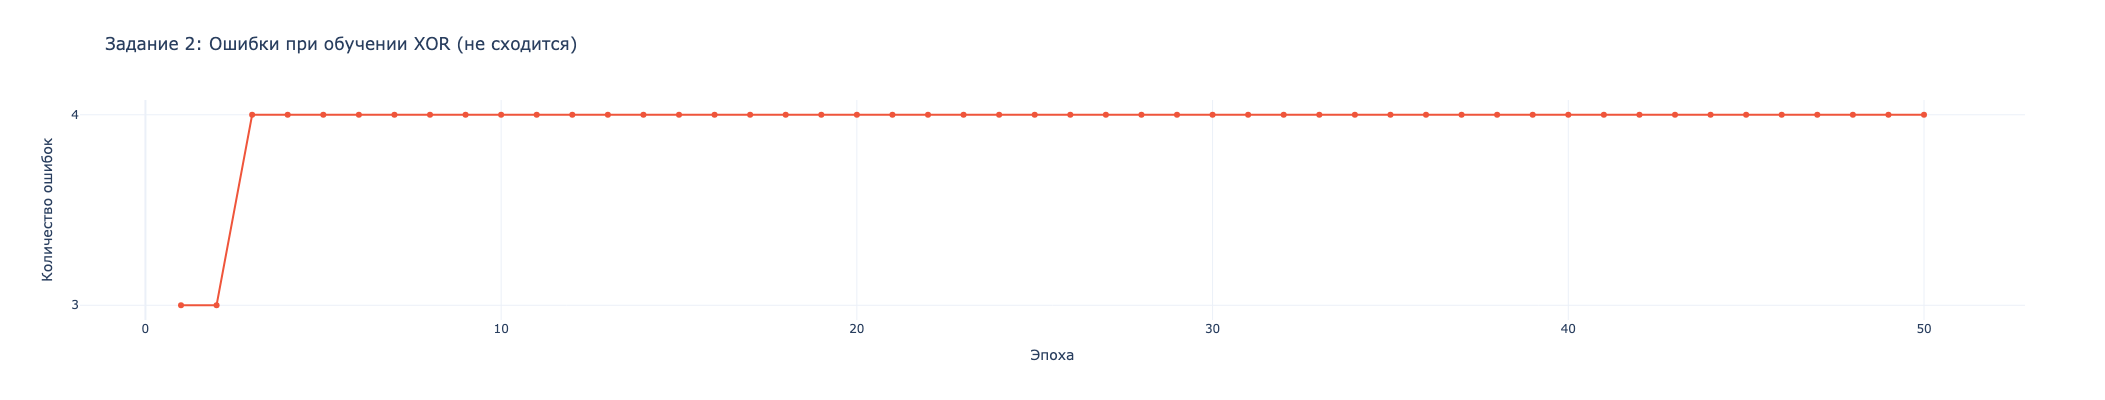

In [10]:
fig_xor_conv = go.Figure()
fig_xor_conv.add_trace(go.Scatter(
    x=list(range(1, len(perc_xor.errors_per_epoch) + 1)),
    y=perc_xor.errors_per_epoch,
    mode='lines+markers',
    marker=dict(size=6, color='#EF553B'),
    line=dict(width=2, color='#EF553B'),
    name='Ошибки'
))
fig_xor_conv.update_layout(
    title='Задание 2: Ошибки при обучении XOR (не сходится)',
    xaxis_title='Эпоха',
    yaxis_title='Количество ошибок',
    yaxis=dict(dtick=1),
    template='plotly_white',
    width=700, height=400
)
fig_xor_conv.write_html('report/outputs/task2_xor_convergence.html')
fig_xor_conv.show()

### Вывод по XOR

Как видно из графиков, персептрон не может достичь нулевой ошибки на задаче XOR. Количество ошибок осциллирует и никогда не снижается до нуля. Это фундаментальное ограничение однослойного персептрона: он способен решать только **линейно разделимые** задачи.

Точки класса 0 — $(0,0)$ и $(1,1)$ — расположены по диагонали, как и точки класса 1 — $(0,1)$ и $(1,0)$. Никакая одна прямая не может разделить эти две группы.

---
## Задание 3: Персептрон из двух нейронов для 4 классов

Для классификации на 4 класса используем **2 выходных нейрона**. Каждый нейрон делит пространство на две полуплоскости, а их комбинация даёт 4 области, соответствующие кодам классов:

| Нейрон 1 | Нейрон 2 | Класс |
|:---:|:---:|:---:|
| 0 | 0 | 0 |
| 0 | 1 | 1 |
| 1 | 0 | 2 |
| 1 | 1 | 3 |

Сгенерируем 4 кластера точек и обучим персептрон из двух нейронов.

In [11]:
np.random.seed(42)

n_per_class = 25
std = 0.3

centers = {
    0: (-2, -2),  # код: 00
    1: (-2, +2),  # код: 01
    2: (+2, -2),  # код: 10
    3: (+2, +2),  # код: 11
}

X_all = []
t_all = []

for cls, (cx, cy) in centers.items():
    points = np.column_stack([
        np.random.randn(n_per_class) * std + cx,
        np.random.randn(n_per_class) * std + cy
    ])
    X_all.append(points)
    t_all.extend([cls] * n_per_class)

X4 = np.vstack(X_all)
t4 = np.array(t_all)

print(f"Всего точек: {len(X4)}")
for cls in range(4):
    code = f"{cls:02b}"
    print(f"  Класс {cls} (код {code}): центр = {centers[cls]}, точек = {np.sum(t4 == cls)}")

Всего точек: 100
  Класс 0 (код 00): центр = (-2, -2), точек = 25
  Класс 1 (код 01): центр = (-2, 2), точек = 25
  Класс 2 (код 10): центр = (2, -2), точек = 25
  Класс 3 (код 11): центр = (2, 2), точек = 25


In [12]:
class TwoNeuronPerceptron:
    """Персептрон с двумя выходными нейронами для классификации на 4 класса."""

    def __init__(self, n_inputs, learning_rate=1.0):
        self.neuron1 = Perceptron(n_inputs, learning_rate)
        self.neuron2 = Perceptron(n_inputs, learning_rate)
        self.errors_per_epoch = []
        self.weights_history_n1 = []
        self.bias_history_n1 = []
        self.weights_history_n2 = []
        self.bias_history_n2 = []

    def class_to_targets(self, classes):
        """Преобразование номера класса в целевые значения двух нейронов.
        Класс 0 → (0,0), Класс 1 → (0,1), Класс 2 → (1,0), Класс 3 → (1,1)
        """
        t1 = (classes >> 1) & 1  # старший бит
        t2 = classes & 1         # младший бит
        return t1, t2

    def predict(self, x):
        y1 = self.neuron1.predict(x)
        y2 = self.neuron2.predict(x)
        return y1 * 2 + y2

    def predict_batch(self, X):
        return np.array([self.predict(x) for x in X])

    def fit(self, X, classes, max_epochs=100):
        t1, t2 = self.class_to_targets(classes)
        self.errors_per_epoch = []
        self.weights_history_n1 = []
        self.bias_history_n1 = []
        self.weights_history_n2 = []
        self.bias_history_n2 = []

        self.weights_history_n1.append(self.neuron1.weights.copy())
        self.bias_history_n1.append(self.neuron1.bias)
        self.weights_history_n2.append(self.neuron2.weights.copy())
        self.bias_history_n2.append(self.neuron2.bias)

        for epoch in range(max_epochs):
            errors = 0
            for xi, ti1, ti2 in zip(X, t1, t2):
                y1 = self.neuron1.predict(xi)
                y2 = self.neuron2.predict(xi)

                e1 = ti1 - y1
                e2 = ti2 - y2

                if e1 != 0:
                    self.neuron1.weights += self.neuron1.lr * e1 * xi
                    self.neuron1.bias += self.neuron1.lr * e1
                    errors += 1
                if e2 != 0:
                    self.neuron2.weights += self.neuron2.lr * e2 * xi
                    self.neuron2.bias += self.neuron2.lr * e2
                    errors += 1

            self.errors_per_epoch.append(errors)
            self.weights_history_n1.append(self.neuron1.weights.copy())
            self.bias_history_n1.append(self.neuron1.bias)
            self.weights_history_n2.append(self.neuron2.weights.copy())
            self.bias_history_n2.append(self.neuron2.bias)
            if errors == 0:
                print(f"Сходимость достигнута на эпохе {epoch + 1}")
                break
        else:
            print(f"Обучение завершено после {max_epochs} эпох")

        return self

In [13]:
perc4 = TwoNeuronPerceptron(n_inputs=2, learning_rate=1.0)
perc4.fit(X4, t4, max_epochs=100)

print(f"\nНейрон 1 (старший бит):")
print(f"  Веса: {perc4.neuron1.weights}")
print(f"  Смещение: {perc4.neuron1.bias}")
print(f"\nНейрон 2 (младший бит):")
print(f"  Веса: {perc4.neuron2.weights}")
print(f"  Смещение: {perc4.neuron2.bias}")

predictions4 = perc4.predict_batch(X4)
accuracy = np.mean(predictions4 == t4) * 100
print(f"\nТочность классификации: {accuracy:.1f}%")

Сходимость достигнута на эпохе 2

Нейрон 1 (старший бит):
  Веса: [ 3.44411375 -0.06240004]
  Смещение: -2.0

Нейрон 2 (младший бит):
  Веса: [-0.05178906  4.21329397]
  Смещение: 0.0

Точность классификации: 100.0%


### Визуализация: точки и две разделяющие границы

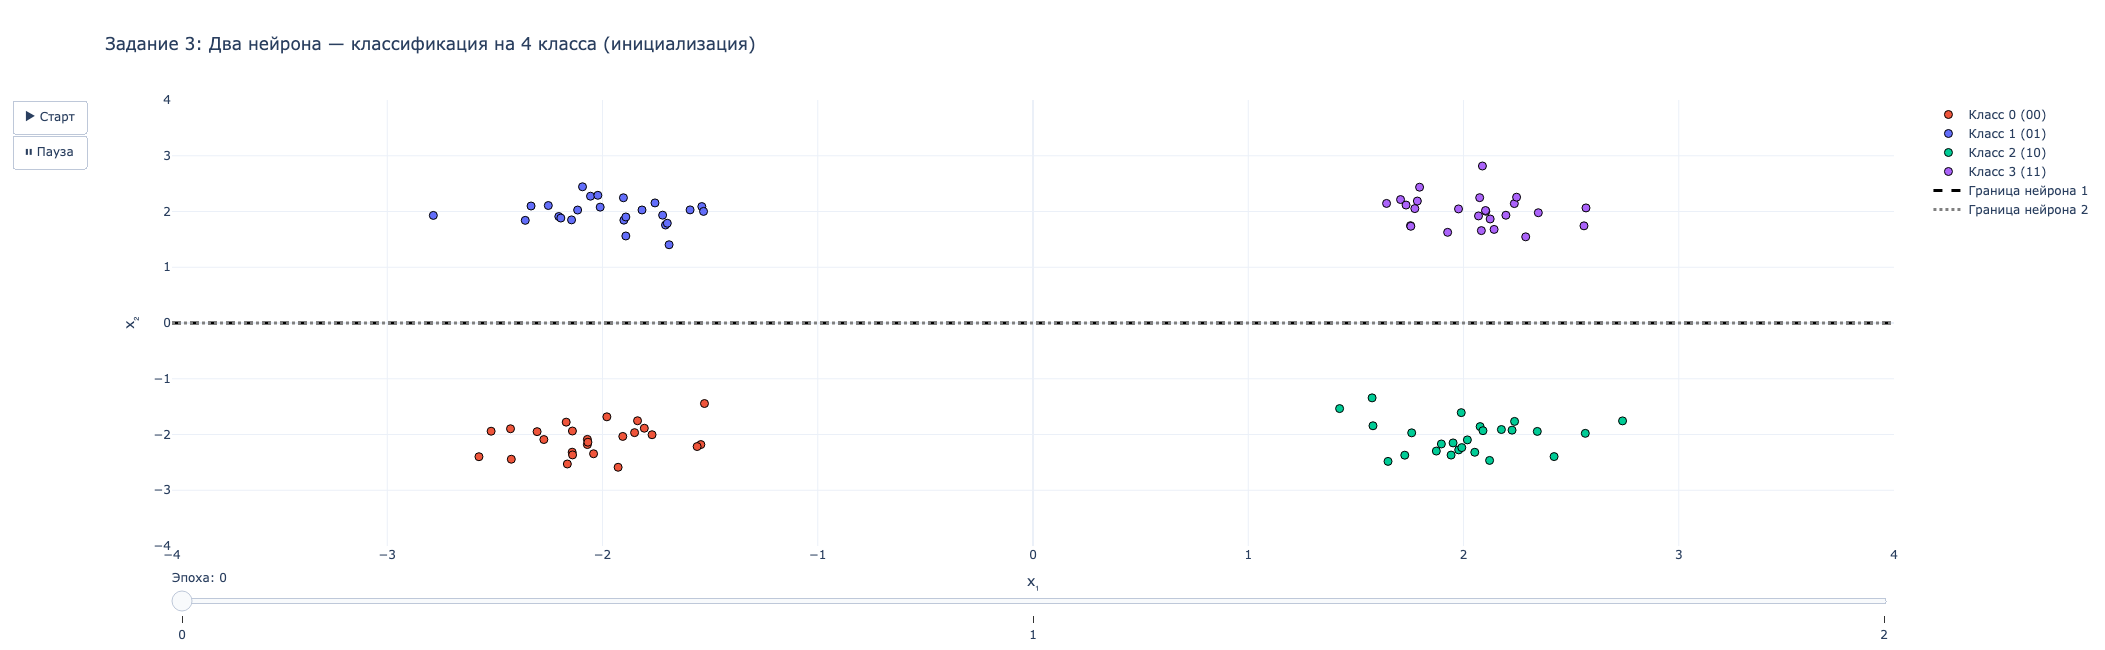

In [14]:
color_map = {0: '#EF553B', 1: '#636EFA', 2: '#00CC96', 3: '#AB63FA'}
class_labels = {
    0: 'Класс 0 (00)',
    1: 'Класс 1 (01)',
    2: 'Класс 2 (10)',
    3: 'Класс 3 (11)'
}

fig4 = go.Figure()

for cls in range(4):
    mask = t4 == cls
    fig4.add_trace(go.Scatter(
        x=X4[mask, 0], y=X4[mask, 1],
        mode='markers',
        marker=dict(size=8, color=color_map[cls], line=dict(width=1, color='black')),
        name=class_labels[cls]
    ))

x_range = np.linspace(-4, 4, 200)

def multi_boundary_xy(weights, bias, y_limits=(-4, 4)):
    if abs(weights[1]) > 1e-9:
        return x_range, -(weights[0] * x_range + bias) / weights[1]
    if abs(weights[0]) > 1e-9:
        x_val = -bias / weights[0]
        return np.array([x_val, x_val]), np.array(y_limits)
    return x_range, np.zeros_like(x_range)

x_b1_0, y_b1_0 = multi_boundary_xy(perc4.weights_history_n1[0], perc4.bias_history_n1[0])
x_b2_0, y_b2_0 = multi_boundary_xy(perc4.weights_history_n2[0], perc4.bias_history_n2[0])

fig4.add_trace(go.Scatter(
    x=x_b1_0, y=y_b1_0,
    mode='lines', line=dict(color='black', width=3, dash='dash'),
    name='Граница нейрона 1'
))
fig4.add_trace(go.Scatter(
    x=x_b2_0, y=y_b2_0,
    mode='lines', line=dict(color='gray', width=3, dash='dot'),
    name='Граница нейрона 2'
))

frames4 = []
for epoch_idx in range(len(perc4.weights_history_n1)):
    x_b1_f, y_b1_f = multi_boundary_xy(perc4.weights_history_n1[epoch_idx], perc4.bias_history_n1[epoch_idx])
    x_b2_f, y_b2_f = multi_boundary_xy(perc4.weights_history_n2[epoch_idx], perc4.bias_history_n2[epoch_idx])
    subtitle = 'инициализация' if epoch_idx == 0 else f'эпоха {epoch_idx}, ошибок: {perc4.errors_per_epoch[epoch_idx - 1]}'
    frames4.append(go.Frame(
        data=[
            go.Scatter(x=x_b1_f, y=y_b1_f),
            go.Scatter(x=x_b2_f, y=y_b2_f),
        ],
        traces=[4, 5],
        name=str(epoch_idx),
        layout=go.Layout(title=f'Задание 3: Два нейрона — классификация на 4 класса ({subtitle})')
    ))

fig4.frames = frames4

fig4.update_layout(
    title='Задание 3: Два нейрона — классификация на 4 класса (инициализация)',
    xaxis_title='x₁', yaxis_title='x₂',
    xaxis=dict(range=[-4, 4]),
    yaxis=dict(range=[-4, 4]),
    template='plotly_white',
    width=750, height=650,
    updatemenus=[dict(
        type='buttons',
        showactive=False,
        buttons=[
            dict(label='▶ Старт', method='animate', args=[None, dict(frame=dict(duration=700, redraw=True), fromcurrent=True)]),
            dict(label='⏸ Пауза', method='animate', args=[[None], dict(frame=dict(duration=0, redraw=False), mode='immediate')]),
        ]
    )],
    sliders=[dict(
        active=0,
        currentvalue=dict(prefix='Эпоха: '),
        steps=[
            dict(
                method='animate',
                args=[[str(i)], dict(frame=dict(duration=0, redraw=True), mode='immediate')],
                label=str(i)
            )
            for i in range(len(frames4))
        ]
    )]
)
fig4.write_html('report/outputs/task3_four_classes.html')
fig4.show()

### Карта решений персептрона

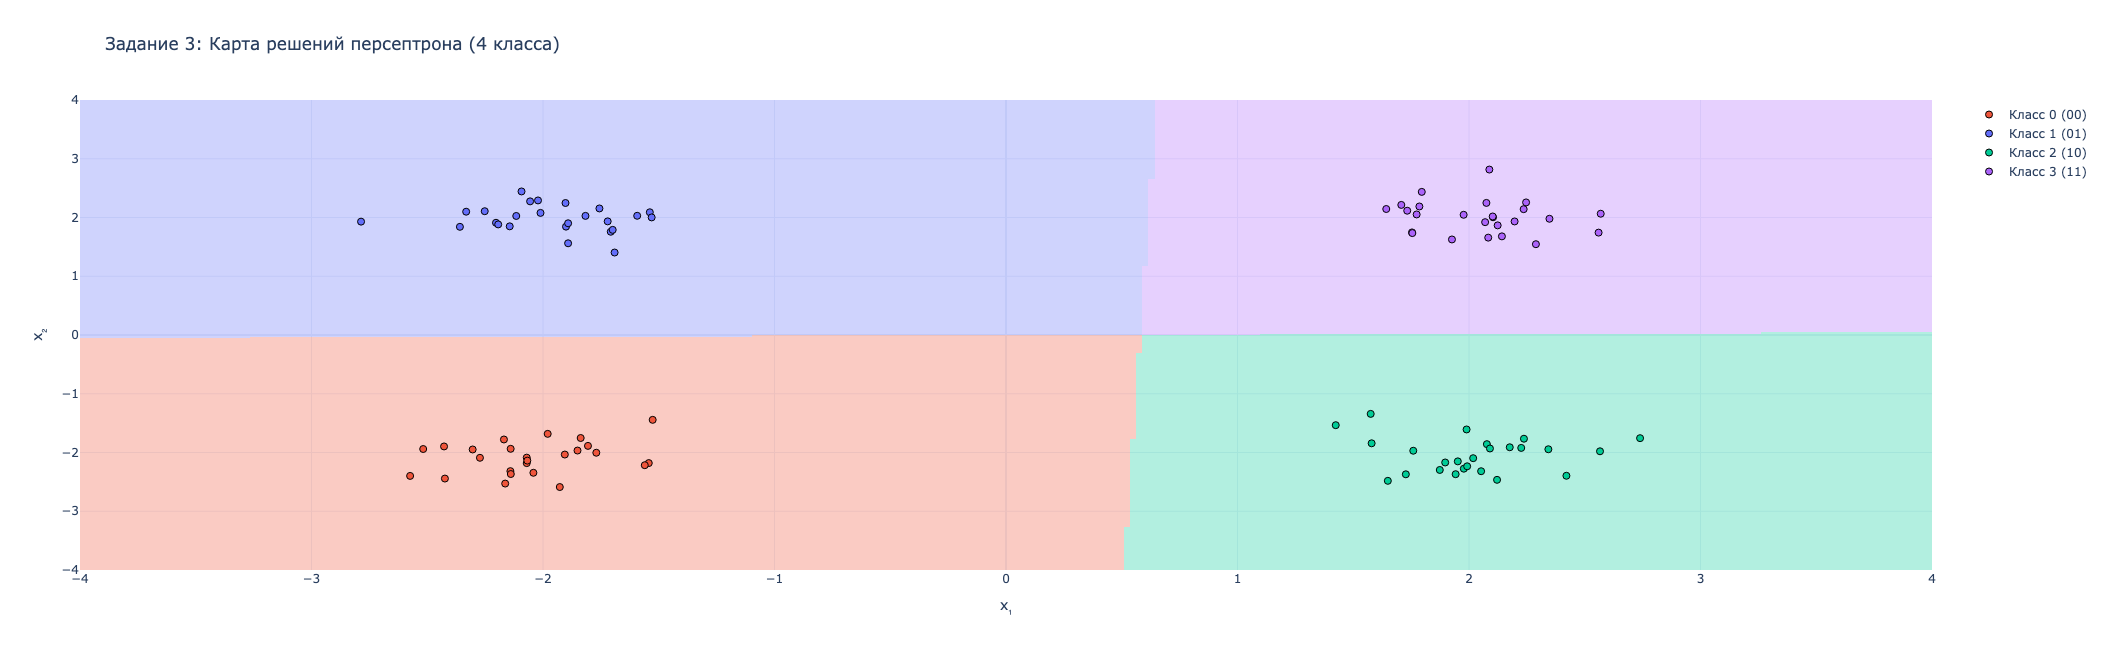

In [15]:
xx, yy = np.meshgrid(np.linspace(-4, 4, 300), np.linspace(-4, 4, 300))
grid_points = np.column_stack([xx.ravel(), yy.ravel()])
grid_predictions = perc4.predict_batch(grid_points).reshape(xx.shape)

fig_map = go.Figure()

fig_map.add_trace(go.Heatmap(
    x=np.linspace(-4, 4, 300),
    y=np.linspace(-4, 4, 300),
    z=grid_predictions,
    colorscale=[
        [0.0, '#EF553B'], [0.33, '#636EFA'],
        [0.66, '#00CC96'], [1.0, '#AB63FA']
    ],
    showscale=False,
    opacity=0.3
))

for cls in range(4):
    mask = t4 == cls
    fig_map.add_trace(go.Scatter(
        x=X4[mask, 0], y=X4[mask, 1],
        mode='markers',
        marker=dict(size=7, color=color_map[cls], line=dict(width=1, color='black')),
        name=class_labels[cls]
    ))

fig_map.update_layout(
    title='Задание 3: Карта решений персептрона (4 класса)',
    xaxis_title='x₁', yaxis_title='x₂',
    xaxis=dict(range=[-4, 4]),
    yaxis=dict(range=[-4, 4]),
    template='plotly_white',
    width=750, height=650
)
fig_map.write_html('report/outputs/task3_decision_map.html')
fig_map.show()

### Сходимость обучения (4 класса)

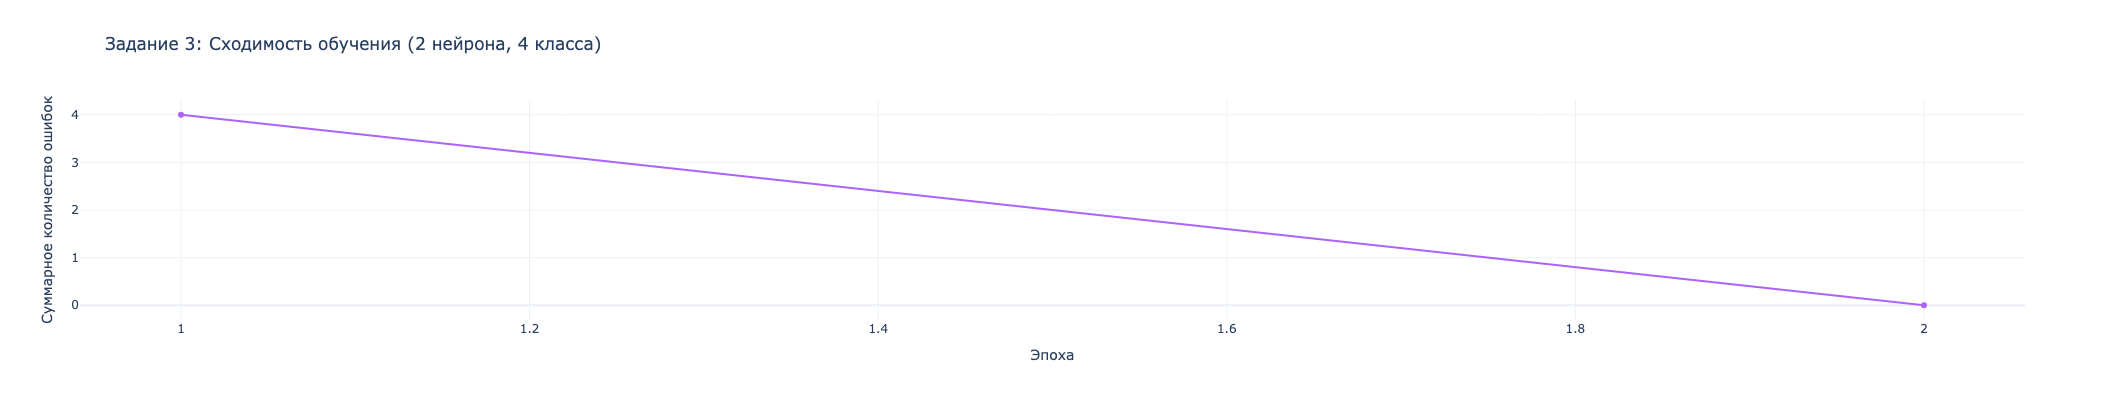

In [16]:
fig_conv4 = go.Figure()
fig_conv4.add_trace(go.Scatter(
    x=list(range(1, len(perc4.errors_per_epoch) + 1)),
    y=perc4.errors_per_epoch,
    mode='lines+markers',
    marker=dict(size=6, color='#AB63FA'),
    line=dict(width=2, color='#AB63FA'),
    name='Ошибки (оба нейрона)'
))
fig_conv4.update_layout(
    title='Задание 3: Сходимость обучения (2 нейрона, 4 класса)',
    xaxis_title='Эпоха',
    yaxis_title='Суммарное количество ошибок',
    template='plotly_white',
    width=700, height=400
)
fig_conv4.write_html('report/outputs/task3_convergence.html')
fig_conv4.show()

---
## Выводы

В ходе лабораторной работы были получены следующие результаты:

1. **Задание 1 (классификация на 2 класса):** Однослойный персептрон успешно обучился классифицировать 4 входных вектора на два класса. Алгоритм сошёлся за небольшое количество эпох, что подтверждает теорему о сходимости персептрона для линейно разделимых данных.

2. **Задание 2 (проблема XOR):** Продемонстрировано фундаментальное ограничение однослойного персептрона — невозможность решения линейно неразделимых задач. Функция XOR не может быть реализована одним нейроном с пороговой активацией, что было доказано Минским и Папертом в 1969 году.

3. **Задание 3 (классификация на 4 класса):** Персептрон из двух нейронов способен классифицировать данные на 4 класса, при условии что каждый нейрон решает линейно разделимую подзадачу. Комбинация выходов двух нейронов (двоичный код) позволяет закодировать 4 различных класса.

**Ключевые выводы:**
- Персептрон гарантированно сходится за конечное число шагов, если данные линейно разделимы.
- Для линейно неразделимых задач (XOR) необходимы многослойные архитектуры.
- Увеличение числа выходных нейронов позволяет расширить число распознаваемых классов.